In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sns.set_style("whitegrid")
%matplotlib inline

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,CustomerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Blank values found:", df["TotalCharges"].isna().sum())
print("Their tenure:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())

Blank values found: 11
Their tenure: [0]


In [9]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df.isna().sum().sum()

np.int64(7043)

In [10]:
total = len(df)
churned = (df["Churn"] == "Yes").sum()
rate = churned / total * 100
print(f"Total customers: {total}")
print(f"Churned: {churned}")
print(f"Churn rate: {rate:.2f}%")

Total customers: 7043
Churned: 1869
Churn rate: 26.54%


C:\Users\suraj.VIRUS\AppData\Local\Temp\ipykernel_5540\1334485797.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette=["#2E86AB", "#E63946"])


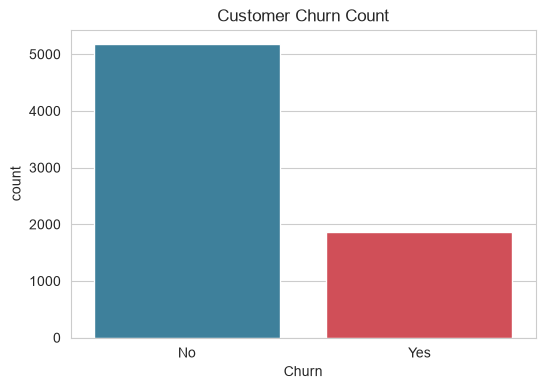

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", palette=["#2E86AB", "#E63946"])
plt.title("Customer Churn Count")
plt.show()

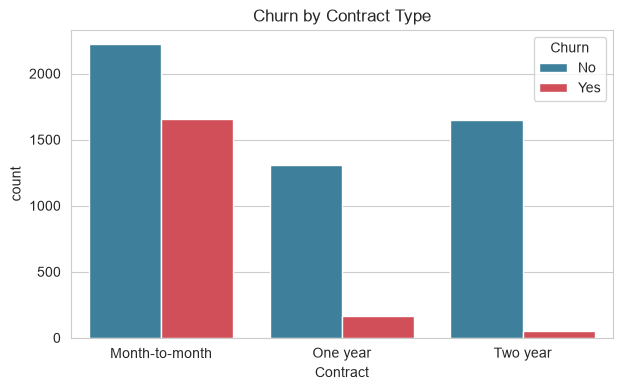

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", hue="Churn", palette=["#2E86AB", "#E63946"])
plt.title("Churn by Contract Type")
plt.show()

In [13]:
contingency = pd.crosstab(df["Contract"], df["Churn"])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print("Chi-square statistic:", round(chi2, 2))
print("p-value:", p_value)

Chi-square statistic: 1184.6
p-value: 5.863038300673391e-258


In [14]:
df_stats = df.drop(columns=["CustomerID"]).copy()
df_stats["Churn"] = df_stats["Churn"].map({"No": 0, "Yes": 1})
df_stats = pd.get_dummies(df_stats, drop_first=True)

X_stats = sm.add_constant(df_stats.drop(columns=["Churn"]).astype(float))
y_stats = df_stats["Churn"].astype(float)

In [15]:
logit_model = sm.Logit(y_stats, X_stats)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.414225
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7043
Model:                          Logit   Df Residuals:                     7020
Method:                           MLE   Df Model:                           22
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                  0.2841
Time:                        01:29:41   Log-Likelihood:                -2917.4
converged:                       True   LL-Null:                       -4075.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
const                                     0.8300      

In [16]:
X = df_stats.drop(columns=["Churn"])
y = df_stats["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("Precision:", round(precision_score(y_test, pred), 3))
print("Recall:", round(recall_score(y_test, pred), 3))
print("F1:", round(f1_score(y_test, pred), 3))

Accuracy: 0.752
Precision: 0.521
Recall: 0.794
F1: 0.629


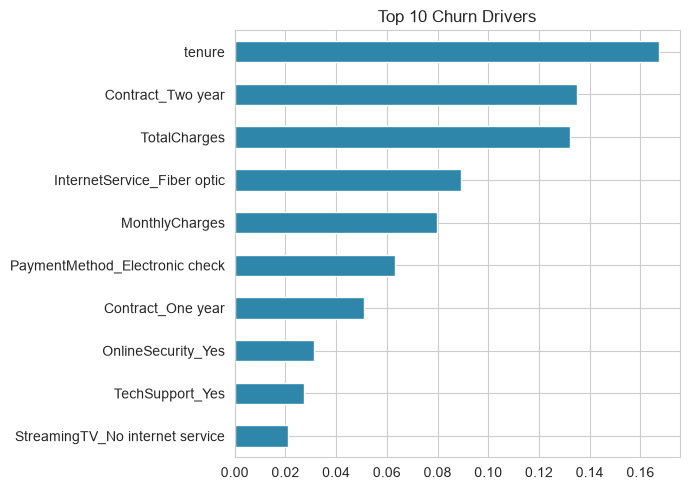

tenure                             0.167242
Contract_Two year                  0.135108
TotalCharges                       0.132142
InternetService_Fiber optic        0.089181
MonthlyCharges                     0.079651
PaymentMethod_Electronic check     0.063247
Contract_One year                  0.050938
OnlineSecurity_Yes                 0.031110
TechSupport_Yes                    0.027174
StreamingTV_No internet service    0.020841
dtype: float64


In [17]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
importances.sort_values().plot(kind="barh", color="#2E86AB")
plt.title("Top 10 Churn Drivers")
plt.tight_layout()
plt.show()

print(importances)

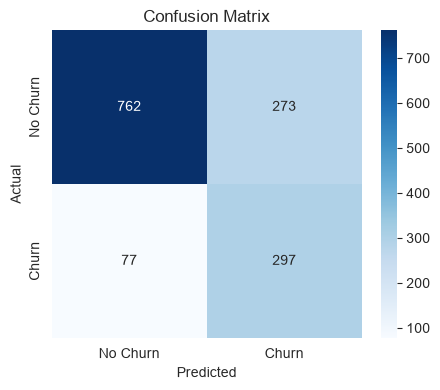

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
import joblib
import os

os.makedirs("model", exist_ok=True)
joblib.dump(model, "model/churn_model.pkl")
joblib.dump(list(X.columns), "model/feature_columns.pkl")
print("Model saved to model/churn_model.pkl")

Model saved to model/churn_model.pkl
